In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

Предобработка данных

In [21]:
df = pd.read_csv('Weather_Data.csv')


Загружаю данные, стирая разделитель

In [22]:
df.head()

,Date,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2/1/2008,19.5,22.4,15.6,6.2,0.0,W,41,S,SSW,...,92,84,1017.6,1017.4,8,8,20.7,20.9,Yes,Yes
1,2/2/2008,19.5,25.6,6.0,3.4,2.7,W,41,W,E,...,83,73,1017.9,1016.4,7,7,22.4,24.8,Yes,Yes
2,2/3/2008,21.6,24.5,6.6,2.4,0.1,W,41,ESE,ESE,...,88,86,1016.7,1015.6,7,8,23.5,23.0,Yes,Yes
3,2/4/2008,20.2,22.8,18.8,2.2,0.0,W,41,NNE,E,...,83,90,1014.2,1011.8,8,8,21.4,20.9,Yes,Yes
4,2/5/2008,19.7,25.7,77.4,4.8,0.0,W,41,NNE,W,...,88,74,1008.3,1004.8,8,8,22.5,25.5,Yes,Yes


In [23]:
df.describe()


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,3271.000000,3271.000000,3271.000000,3271.000000,3271.000000,3271.000000,3271.000000,3271.000000,3271.000000,3271.000000,3271.000000,3271.000000,3271.000000,3271.000000,3271.000000,3271.000000
mean,14.877102,23.005564,3.342158,5.175787,7.168970,41.476307,15.077041,19.294405,68.243962,54.698563,1018.334424,1016.003085,4.318557,4.176093,17.821461,21.543656
std,4.554710,4.483752,9.917746,2.757684,3.815966,10.806951,7.043825,7.453331,15.086127,16.279241,7.020090,7.019915,2.526923,2.411274,4.894316,4.297053
min,4.300000,11.700000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,19.000000,10.000000,986.700000,989.800000,0.000000,0.000000,6.400000,10.200000
25%,11.000000,19.600000,0.000000,3.200000,4.250000,35.000000,11.000000,15.000000,58.000000,44.000000,1013.700000,1011.300000,2.000000,2.000000,13.800000,18.400000
50%,14.900000,22.800000,0.000000,4.800000,8.300000,41.000000,15.000000,19.000000,69.000000,56.000000,1018.600000,1016.300000,5.000000,4.000000,18.200000,21.300000
75%,18.800000,26.000000,1.400000,7.000000,10.200000,44.000000,20.000000,24.000000,80.000000,64.000000,1023.100000,1020.800000,7.000000,7.000000,21.700000,24.500000
max,27.600000,45.800000,119.400000,18.400000,13.600000,96.000000,54.000000,57.000000,100.000000,99.000000,1039.000000,1036.700000,9.000000,8.000000,36.500000,44.700000


In [24]:
df.dtypes

Date              object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed      int64
WindDir9am        object
WindDir3pm        object
WindSpeed9am       int64
WindSpeed3pm       int64
Humidity9am        int64
Humidity3pm        int64
Pressure9am      float64
Pressure3pm      float64
Cloud9am           int64
Cloud3pm           int64
Temp9am          float64
Temp3pm          float64
RainToday         object
RainTomorrow      object
dtype: object

Описание датасета

- **Date (дата)** – день наблюдения; в формате `object`, лучше перевести в `datetime`.  
- **MinTemp (минимальная температура)** – минимальная температура за день (°C).  
- **MaxTemp (максимальная температура)** – максимальная температура за день (°C).  
- **Rainfall (осадки)** – количество осадков за день (мм).  
- **Evaporation (испарение)** – количество испарившейся влаги за день (мм).  
- **Sunshine (солнечные часы)** – количество часов солнечного света.  
- **WindGustDir (направление порывов ветра)** – направление сильного ветра (категориальное).  
- **WindGustSpeed (скорость порывов ветра)** – максимальная скорость порывов ветра (км/ч).  
- **WindDir9am (направление ветра в 9 утра)** – направление ветра утром (категориальное).  
- **WindDir3pm (направление ветра в 3 дня)** – направление ветра днем (категориальное).  
- **WindSpeed9am (скорость ветра в 9 утра)** – скорость ветра утром (км/ч).  
- **WindSpeed3pm (скорость ветра в 3 дня)** – скорость ветра днем (км/ч).  
- **Humidity9am (влажность в 9 утра)** – относительная влажность воздуха утром (%).  
- **Humidity3pm (влажность в 3 дня)** – относительная влажность воздуха днем (%).  
- **Pressure9am (давление в 9 утра)** – атмосферное давление утром (кПа).  
- **Pressure3pm (давление в 3 дня)** – атмосферное давление днем (кПа).  
- **Cloud9am (облачность в 9 утра)** – количество облаков утром (октасы, 0–8).  
- **Cloud3pm (облачность в 3 дня)** – количество облаков днем (октасы, 0–8).  
- **Temp9am (температура в 9 утра)** – температура воздуха утром (°C).  
- **Temp3pm (температура в 3 дня)** – температура воздуха днем (°C).  
- **RainToday (дождь сегодня)** – была ли дождь в этот день (Yes/No).  
- **RainTomorrow (дождь завтра)** – цель предсказания: будет ли дождь завтра (Yes/No).  


В датасете представленно несколько категориальных и числовых переменных. Есть также бинарные

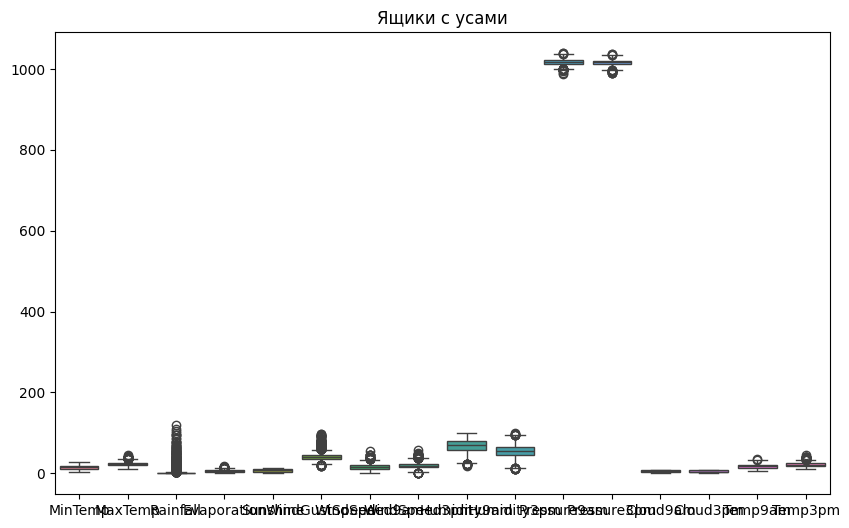

In [25]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10, 6))
sns.boxplot(data=numeric_df)
plt.title('Ящики с усами')
plt.show()

Выбросы присутствуют в duration, age, campaning, pdays, previos, ins.cof

In [26]:
df.isnull().sum()

Date             0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
RainTomorrow     0
dtype: int64

Пропусков нет

In [27]:
df.duplicated().sum()

np.int64(0)

Дубликатов нет.
Посмотрю что по корелляциям между переменными.


Размер числовых признаков: (3271, 16)


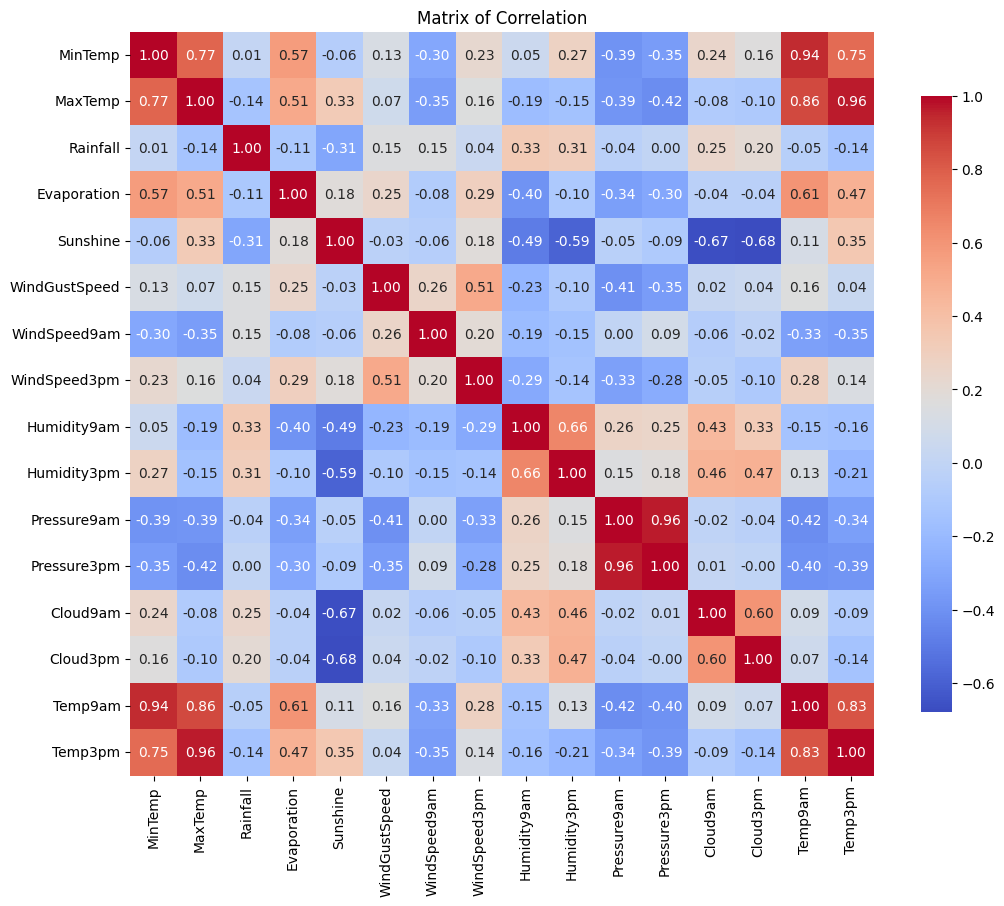

In [28]:
numeric_features = df.select_dtypes(include=['number'])
print("Размер числовых признаков:", numeric_features.shape)

correlation_matrix = numeric_features.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Matrix of Correlation')
plt.show()

На матрице корелляций вижу большое число различных значений. 

Меня интересует предсказание температуры и влияние на нее различных параметров

#### Графики для каждых значений по месяцам для выявления тенденций на повышение температуры с годами

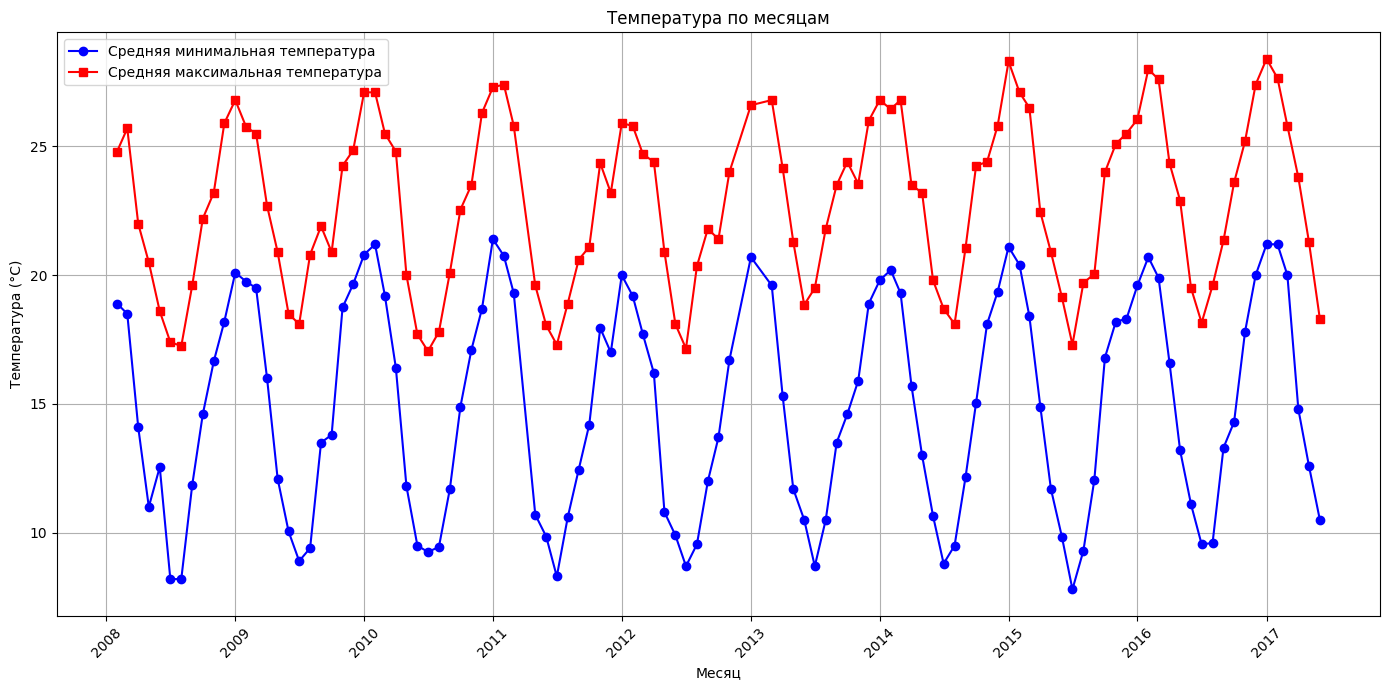

In [29]:
df['Date'] = pd.to_datetime(df['Date'])

df['YearMonth'] = df['Date'].dt.to_period('M')

average_min_temp_monthly = df.groupby('YearMonth')['MinTemp'].median().reset_index()
average_max_temp_monthly = df.groupby('YearMonth')['MaxTemp'].median().reset_index()

plt.figure(figsize=(14, 7))

plt.plot(average_min_temp_monthly['YearMonth'].dt.to_timestamp(), average_min_temp_monthly['MinTemp'], 
         marker='o', linestyle='-', color='b', label='Средняя минимальная температура')

plt.plot(average_max_temp_monthly['YearMonth'].dt.to_timestamp(), average_max_temp_monthly['MaxTemp'], 
         marker='s', linestyle='-', color='r', label='Средняя максимальная температура')

plt.title('Температура по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Температура (°C)')
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

Рассматриваю как могла измениться средняя минимальная и максимальная температура по месяцам в течении всех лет. Вижу, что с годами температура увеличивалась, что может говорить о тенденции к  потеплению.

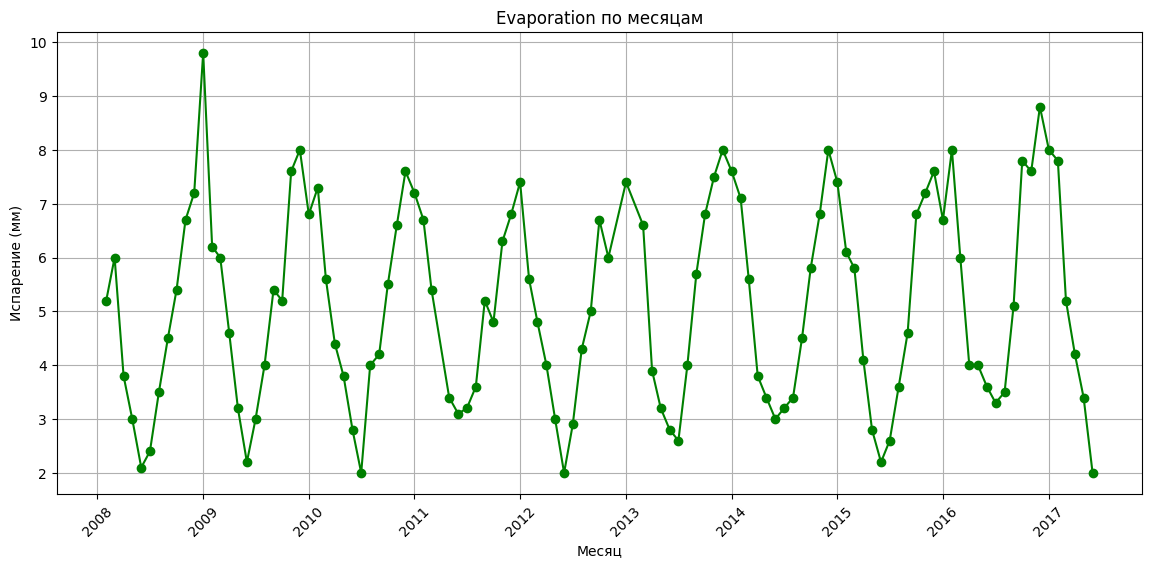

In [30]:
monthly_evaporation = df.groupby('YearMonth')['Evaporation'].median().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(monthly_evaporation['YearMonth'].dt.to_timestamp(), monthly_evaporation['Evaporation'], 
         marker='o', linestyle='-', color='green')
plt.title('Evaporation по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Испарение (мм)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


Испарение также увеличивается со временем

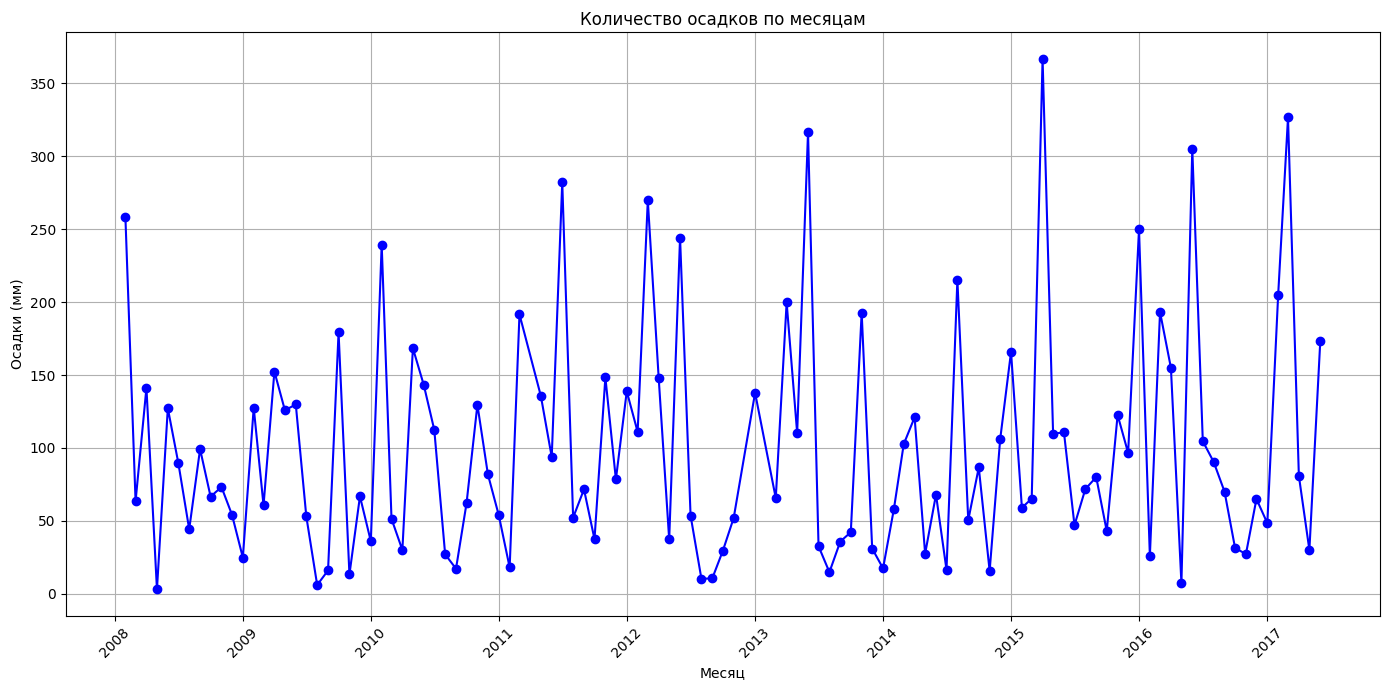

In [31]:
df['Date'] = pd.to_datetime(df['Date'])

df['YearMonth'] = df['Date'].dt.to_period('M')

average_rainfall_monthly = df.groupby('YearMonth')['Rainfall'].sum().reset_index()

plt.figure(figsize=(14, 7))

plt.plot(average_rainfall_monthly['YearMonth'].dt.to_timestamp(), average_rainfall_monthly['Rainfall'], 
         marker='o', linestyle='-', color='b')
plt.title('Количество осадков по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Осадки (мм)')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

Осадков тоже больше начинает выпадать

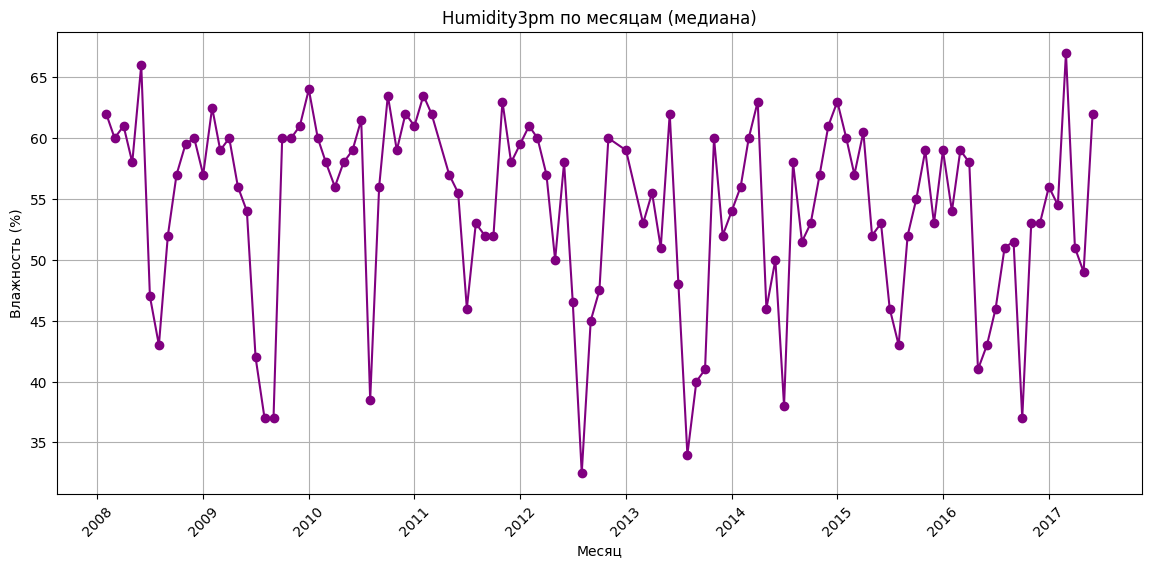

In [32]:
monthly_humidity = df.groupby('YearMonth')['Humidity3pm'].median().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(monthly_humidity['YearMonth'].dt.to_timestamp(), monthly_humidity['Humidity3pm'], 
         marker='o', linestyle='-', color='purple')
plt.title('Humidity3pm по месяцам (медиана)')
plt.xlabel('Месяц')
plt.ylabel('Влажность (%)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


Влажность с годами увеличивается

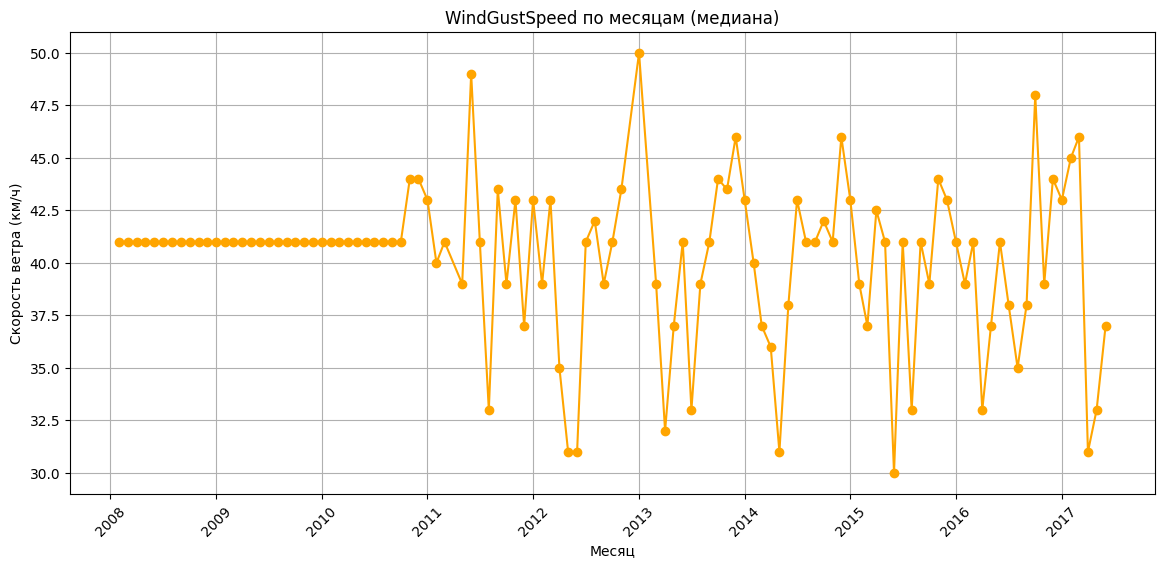

In [33]:
monthly_wind = df.groupby('YearMonth')['WindGustSpeed'].median().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(monthly_wind['YearMonth'].dt.to_timestamp(), monthly_wind['WindGustSpeed'], 
         marker='o', linestyle='-', color='orange')
plt.title('WindGustSpeed по месяцам (медиана)')
plt.xlabel('Месяц')
plt.ylabel('Скорость ветра (км/ч)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


Ветра усиливаются

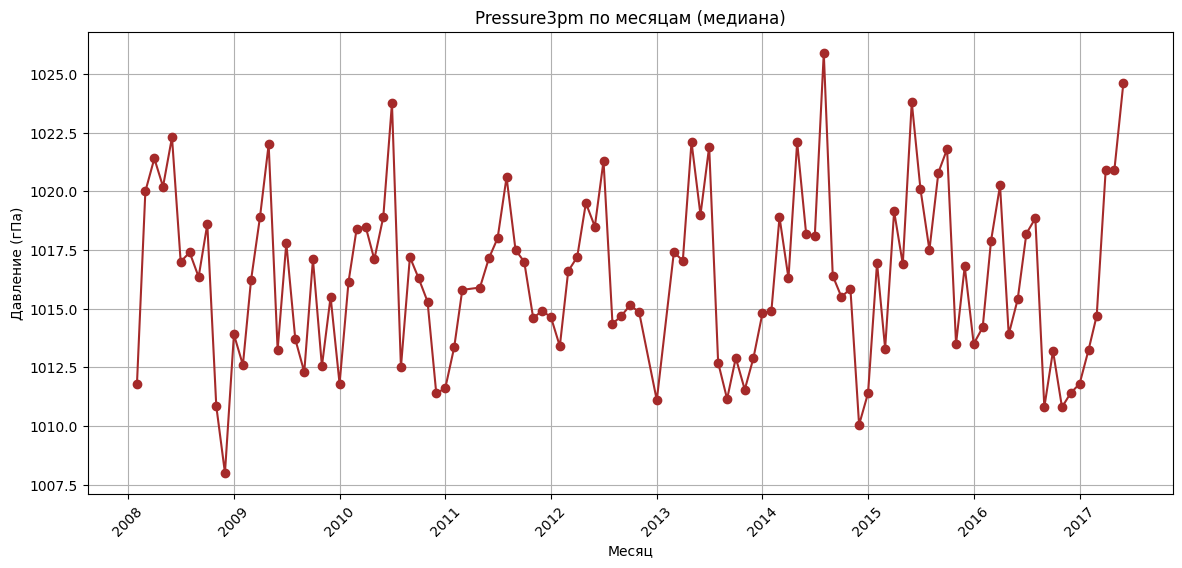

In [34]:
monthly_pressure = df.groupby('YearMonth')['Pressure3pm'].median().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(monthly_pressure['YearMonth'].dt.to_timestamp(), monthly_pressure['Pressure3pm'], 
         marker='o', linestyle='-', color='brown')
plt.title('Pressure3pm по месяцам (медиана)')
plt.xlabel('Месяц')
plt.ylabel('Давление (гПа)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


Давление также увеличивается


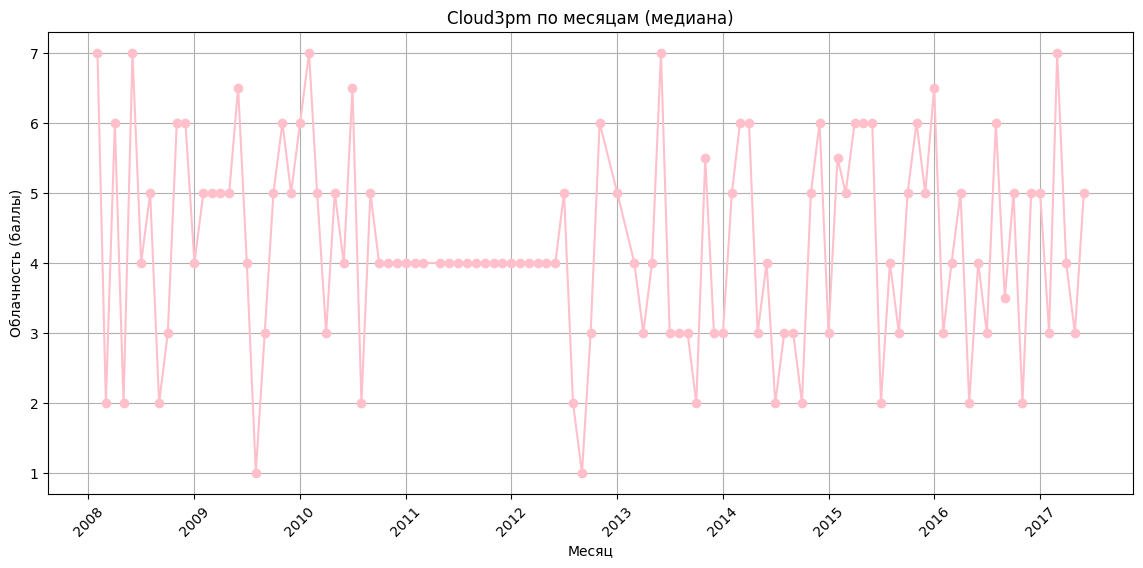

In [35]:
monthly_cloud = df.groupby('YearMonth')['Cloud3pm'].median().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(monthly_cloud['YearMonth'].dt.to_timestamp(), monthly_cloud['Cloud3pm'], 
         marker='o', linestyle='-', color='pink')
plt.title('Cloud3pm по месяцам (медиана)')
plt.xlabel('Месяц')
plt.ylabel('Облачность (баллы)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


Облачность тоже увеличивается

### Сразу все рафики для каждых значений по годам

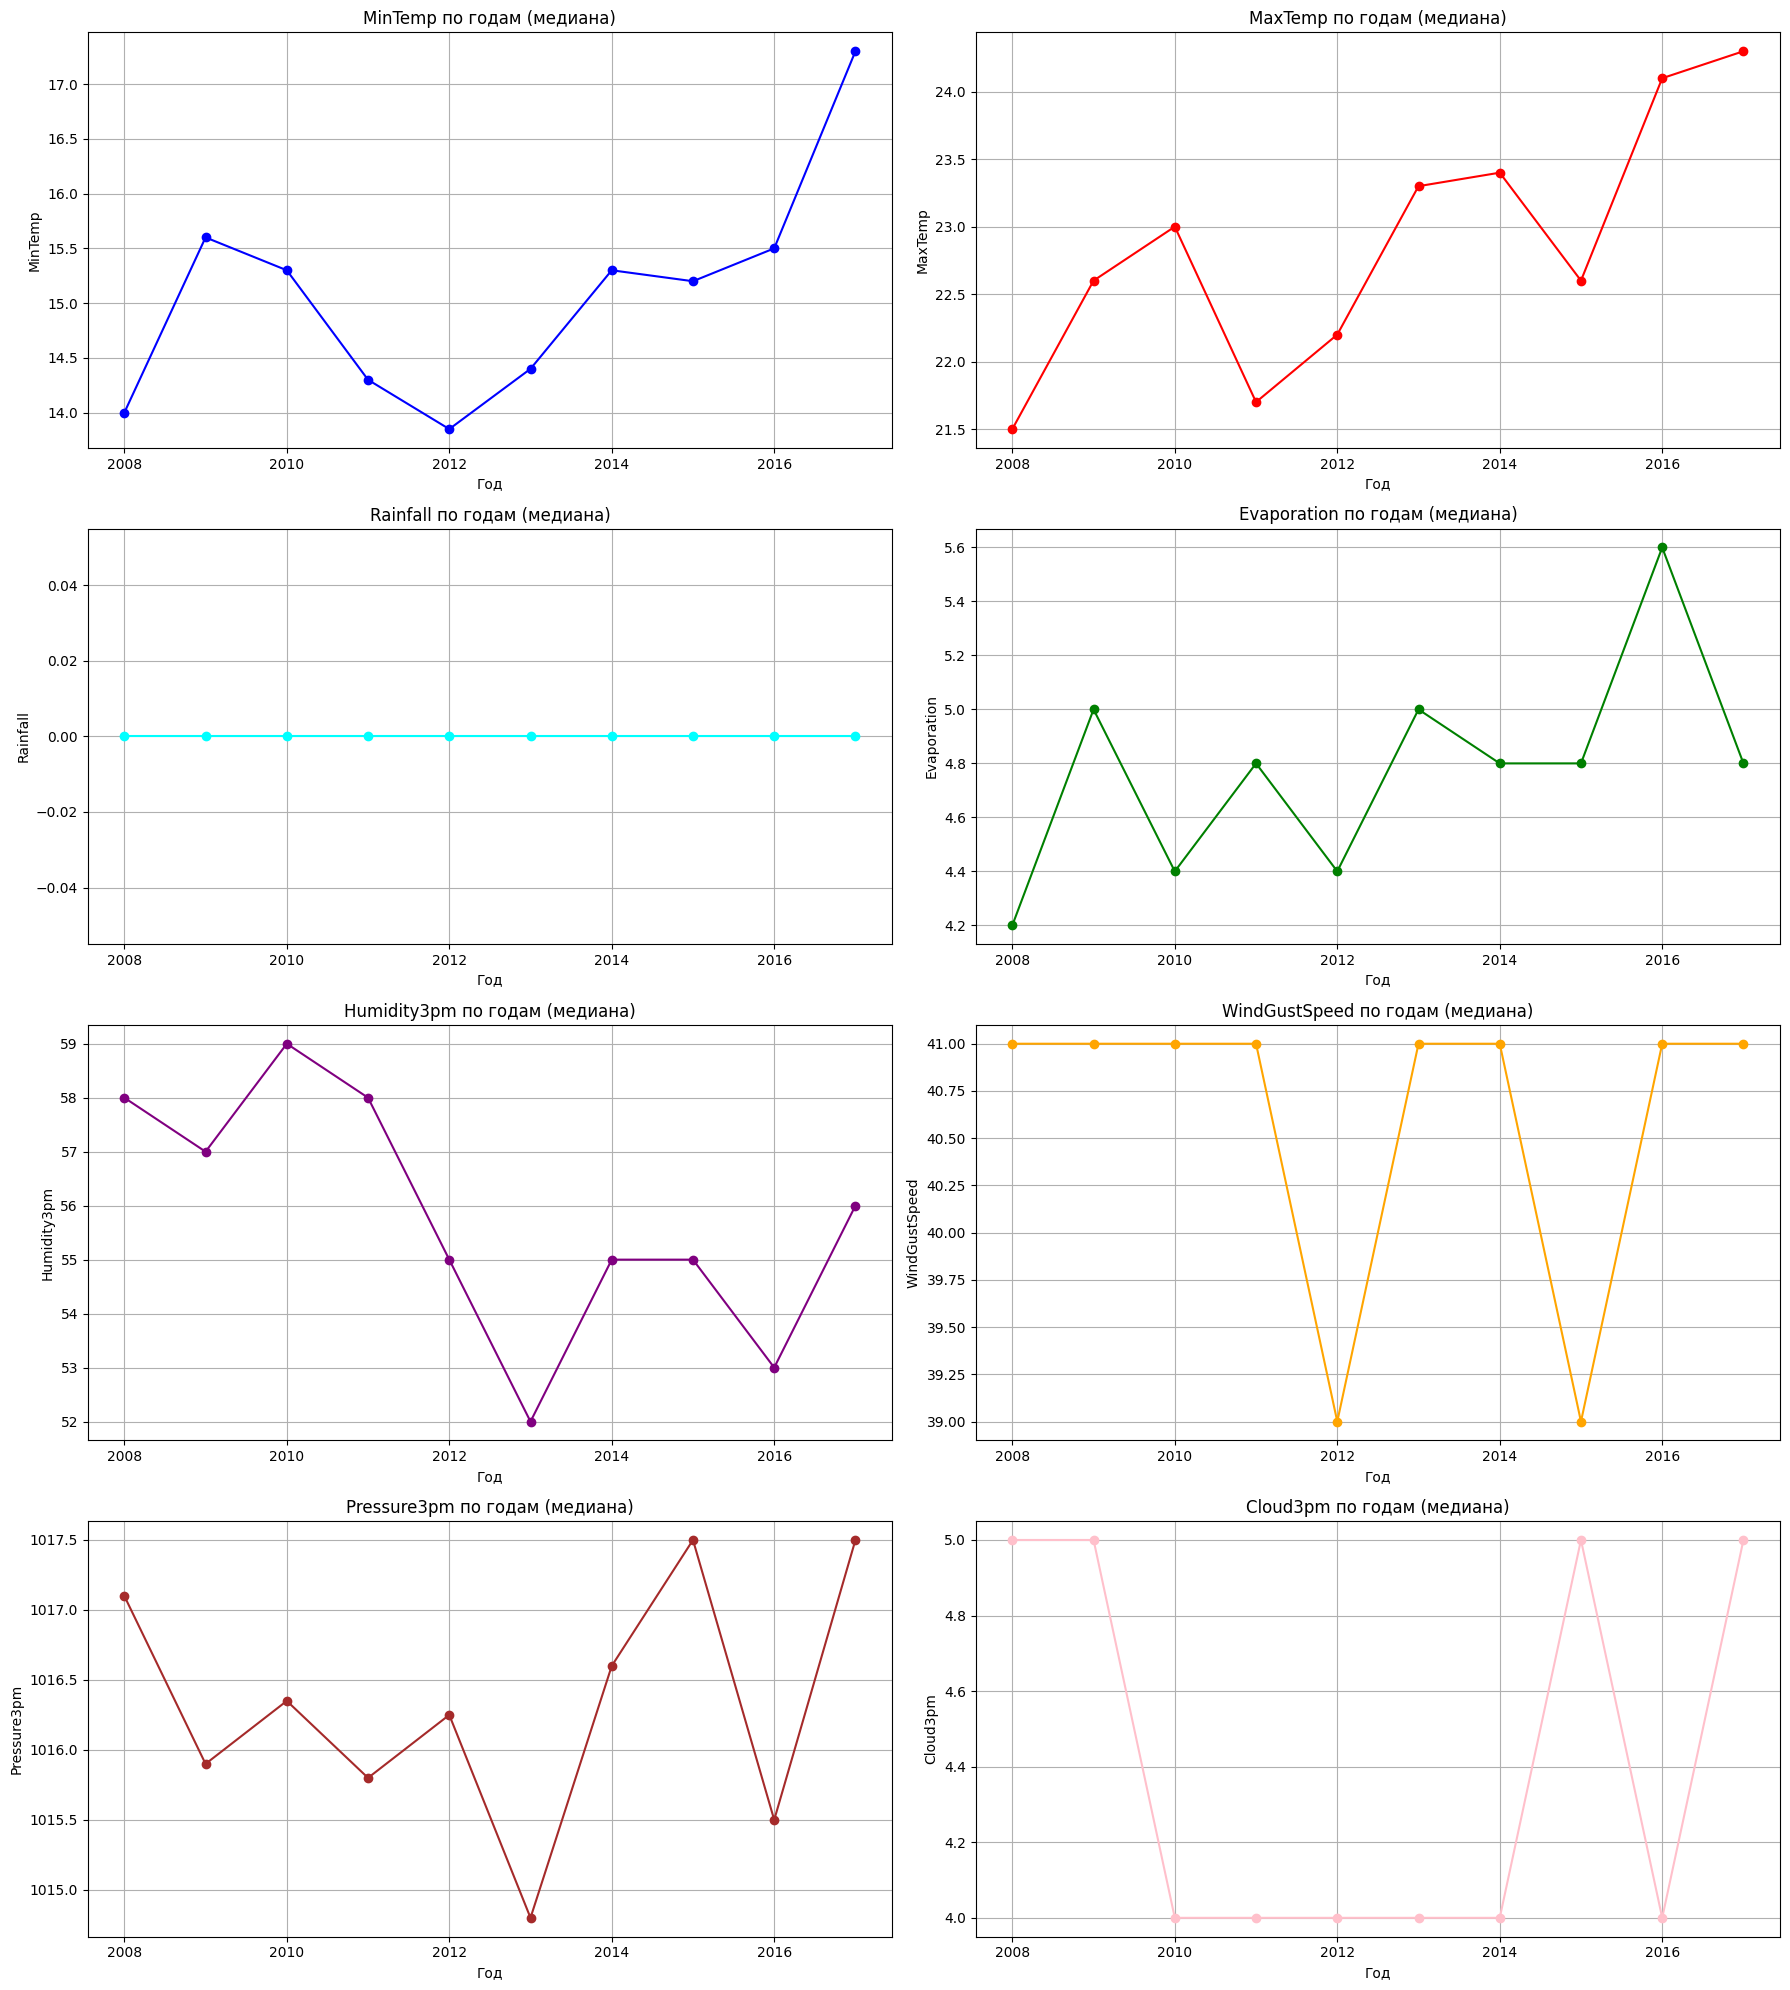

In [36]:
import matplotlib.pyplot as plt
import pandas as pd

df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

features = ["MinTemp", "MaxTemp", "Rainfall", "Evaporation", 
            "Humidity3pm", "WindGustSpeed", "Pressure3pm", "Cloud3pm"]

colors = ['blue', 'red', 'cyan', 'green', 'purple', 'orange', 'brown', 'pink']

plt.figure(figsize=(18, 20))

for i, (feature, color) in enumerate(zip(features, colors)):
    yearly_median = df.groupby('Year')[feature].median().reset_index()
    
    plt.subplot(4, 2, i+1)  
    plt.plot(yearly_median['Year'], yearly_median[feature], 
             marker='o', linestyle='-', color=color)
    plt.title(f'{feature} по годам (медиана)')
    plt.xlabel('Год')
    plt.ylabel(feature)
    plt.grid(True)

plt.tight_layout()
plt.show()


Поскольку в данных присутствуют выбросы, построю графики медианных значений по годам, чтобы оценить тенденцию к повышению минимальной и максимальной температур

In [37]:
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
X = df[["MinTemp", "MaxTemp", "Rainfall", "Evaporation", "Humidity3pm", "WindGustSpeed", "Pressure3pm", "Cloud3pm"]]
y = df["Temp3pm"]

model = LinearRegression()
model.fit(X, y)

coefficients = model.coef_
intercept = model.intercept_

y_pred = model.predict(X)

r_squared = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)

print("Коэффициенты: ", coefficients)
print("Свободный член (интерсепт): ", intercept)
print("Коэффициент детерминации R^2:", r_squared)
print("Средняя абсолютная ошибка (MAE):", mae)

X_with_const = sm.add_constant(X)

model_ols = sm.OLS(y, X_with_const).fit()

p_values = model_ols.pvalues

print("P-значения:\n", p_values)

alpha_check_p = (p_values[1] < 0.015)  

print("P-значение для первого коэффициента меньше 0.015:", alpha_check_p)

Коэффициенты:  [ 0.22705135  0.76553636  0.00926941 -0.10425151 -0.04366924 -0.01776767
  0.01638543 -0.05678895]
Свободный член (интерсепт):  -12.222109567110994
Коэффициент детерминации R^2: 0.9417440617433985
Средняя абсолютная ошибка (MAE): 0.7590279450762163
P-значения:
 const             1.386018e-04
MinTemp          3.122460e-128
MaxTemp           0.000000e+00
Rainfall          3.051575e-06
Evaporation       1.126709e-32
Humidity3pm      1.266576e-138
WindGustSpeed     9.657746e-21
Pressure3pm       1.304024e-07
Cloud3pm          7.607577e-11
dtype: float64
P-значение для первого коэффициента меньше 0.015: True


C:\Users\W\AppData\Local\Temp\ipykernel_3212\1410843751.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha_check_p = (p_values[1] < 0.015)


In [38]:
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

X = df[["MinTemp", "MaxTemp", "Rainfall", "Evaporation", "Humidity3pm", "WindGustSpeed", "Pressure3pm", "Cloud3pm"]]
y = df["Temp3pm"]

model = LinearRegression()
model.fit(X, y)

coefficients = model.coef_
intercept = model.intercept_

y_pred = model.predict(X)

r_squared = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)

print("Коэффициенты: ", coefficients)
print("Свободный член (интерсепт): ", intercept)
print("Коэффициент детерминации R^2:", r_squared)
print("Средняя абсолютная ошибка (MAE):", mae)

X_with_const = sm.add_constant(X)

model_ols = sm.OLS(y, X_with_const).fit()

p_values = model_ols.pvalues

print("P-значения:\n", p_values)

alpha_check_p = (p_values[1] < 0.015)

print("P-значение для первого коэффициента меньше 0.015:", alpha_check_p)

Коэффициенты:  [ 0.22705135  0.76553636  0.00926941 -0.10425151 -0.04366924 -0.01776767
  0.01638543 -0.05678895]
Свободный член (интерсепт):  -12.222109567110994
Коэффициент детерминации R^2: 0.9417440617433985
Средняя абсолютная ошибка (MAE): 0.7590279450762163
P-значения:
 const             1.386018e-04
MinTemp          3.122460e-128
MaxTemp           0.000000e+00
Rainfall          3.051575e-06
Evaporation       1.126709e-32
Humidity3pm      1.266576e-138
WindGustSpeed     9.657746e-21
Pressure3pm       1.304024e-07
Cloud3pm          7.607577e-11
dtype: float64
P-значение для первого коэффициента меньше 0.015: True


C:\Users\W\AppData\Local\Temp\ipykernel_3212\2832810905.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha_check_p = (p_values[1] < 0.015)


На основе R^2 могу сделать вывод что изменения дневной температурой описываются на 94%. Ошибка MAE в 0.75 также небольшая, что говорит о доверенности в данных. P-value всех значений ниже 0.015, что говорит о статистической значимости показателей. Линейная регрессия модели T описывается следующим уравнением линейной регресии;
$$
T = k_0 + k_1 t_{min} + k_2 t_{max} + k_3 R + k_4 E + k_5 H + k_6 W + k_7 P + k_8 C
$$
И при коэффициентах
$$
\text{T} = -12.2221 + 0.2271\cdot\text{MinTemp} + 0.7655\cdot\text{MaxTemp} + 0.0093\cdot\text{Rainfall} - 0.1043\cdot\text{Evaporation} - 0.0437\cdot\text{Humidity3pm} - 0.0178\cdot\text{WindGustSpeed} + 0.0164\cdot\text{Pressure3pm} - 0.0568\cdot\text{Cloud3pm}
$$

Начальная температура начинается с -12.2 градусов, что скорее всего неинтерпретируемо, возможно это технический параметр.
А вот дальше идут логичные заключения
При увеличении на один градус каждый градус мин. температуры добавляет 0.23 к температуре, а каждый градус макс. температуры добавляет 0.77 к температуре.


В случае с дождем немного необычно, поскольку он должен охлаждать общую температуру, но здесь поднимает, тоесть 1мм осадков увеличивает на 0.0093 градуса температуру.
Испарение на 1мм испарения охлаждают на -0.1 градус температуру
1% влажности охлаждает воздух на -0.04 градуса
1км/ч скорости ветра также охлаждает воздцх на -0.178 градуса
1 кПА  охлаждает воздух на -0.05 градуса
Показатель облачности уменьшает температуру на -0.05 градуса (однако, скорее увеличение давления приводит к увеличению трения молекул и сдерживанию их рядом друг с другом, снижая общую разреженность)

Таким образом, получилась модель, которая при заданных параметрах может предсказывать значения температуры, если известны предсказания параметров, вносящих в нее вклад